# Machine Learning Introduction

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
# Reading the DataFrame from the csv file previously generated
df = pd.read_csv('ecommerce_clean.csv')
print(df.head())

   id_transaccion  id_cliente    producto  precio                fecha  \
0            5001        1103     Teclado    1200  2026-01-01 00:00:00   
1            5002        1436  Smartphone     300  2026-01-01 00:01:00   
2            5004        1107     Teclado    1200  2026-01-01 00:03:00   
3            5005        1072     Teclado     800  2026-01-01 00:04:00   
4            5006        1701     Monitor     800  2026-01-01 00:05:00   

      tienda  edad nivel_suscripcion rango_edad envio_prioritatio  
0  Barcelona  20.0              Free      Joven                Si  
1     Madrid  34.0           Premium     Adulto                Si  
2   Valencia  34.0           Premium     Adulto                Si  
3  Barcelona  34.0             Basic     Adulto                Si  
4   Valencia  34.0              Free     Adulto                Si  


### train_test_split
Function to split the features and target variables to create a train and test subset from each one.

-test_size : ratio of data used to test de model

-random_state : fixes the raddomness of the function to be able to run the code identically each time

-stratify = y : forces the fucntion to get y_test and y_train whith the same proportion of the classes y is divided into

In [3]:
#Definition of the features and target of the model.
X = df[['edad', 'precio']]
y = df['nivel_suscripcion']

#Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

## Features Scaling
-fit() to get the mean and the standard deviation of the training data

-transform() to apply the scala (Z-score normalization) to the dataset (Tipificación)

-fit_transfrom() get the mean and the standard deviation and applies transform() based on that measures

In [ ]:
from sklearn.preprocessing import StandardScaler #Scaler scikitlearn

#Initialize the scaler
scaler = StandardScaler()

#Fit and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

#Transform the test data
X_test_scaled = scaler.transform(X_test)

## Predicction of a Categorical Variable (Classification task, KNN algorithm)

In [5]:
from sklearn.neighbors import KNeighborsClassifier

#Initialize the model
knn = KNeighborsClassifier(n_neighbors= 5)

#Fitting the model
knn.fit(X_train_scaled, y_train)

#Predicting y_values of the X_test subset the model fitted previously
y_pred = knn.predict(X_test_scaled)

print('Perdiction complete')

Perdiction complete


### Testing the Accuracy of the Model

In [6]:
from sklearn.metrics import accuracy_score

#This funtion calculates te proportion of values mached.
accuracy = accuracy_score(y_true = y_test, y_pred = y_pred)
print('The accuracy of the model is:', accuracy)

The accuracy of the model is: 0.32954545454545453


### Classification Report

In [8]:
from sklearn.metrics import classification_report

print(classification_report(y_true = y_test, y_pred = y_pred))

              precision    recall  f1-score   support

       Basic       0.33      0.82      0.47        87
 Desconocido       0.00      0.00      0.00        18
        Free       0.31      0.18      0.23        71
     Premium       0.60      0.03      0.06        88

    accuracy                           0.33       264
   macro avg       0.31      0.26      0.19       264
weighted avg       0.39      0.33      0.24       264



c:\Users\amgar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\amgar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\amgar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# Hyperparameter Tuning

In [9]:
k_neighbors = [1, 3, 5, 7, 9, 11, 13, 15]
accuracies = []

for k in k_neighbors:
    t_model = KNeighborsClassifier(n_neighbors = k)
    t_model.fit(X_train_scaled, y_train)
    y_pred = t_model.predict(X_test_scaled)
    t_acc = accuracy_score(y_true = y_test, y_pred = y_pred)
    accuracies.append(t_acc)

print(accuracies)

[0.32196969696969696, 0.2765151515151515, 0.32954545454545453, 0.32954545454545453, 0.32954545454545453, 0.30303030303030304, 0.30303030303030304, 0.3333333333333333]


### Validation curve
k = 15 is the most accurated model. Lets represent the curve that relates the k neighbors with the accuracy of knn model.

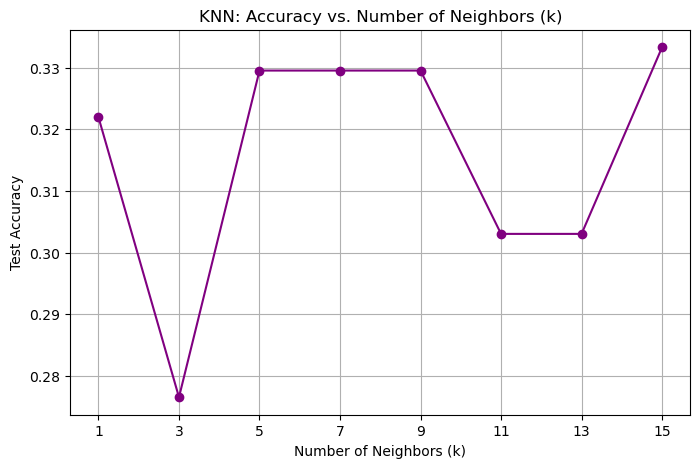

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(k_neighbors, accuracies, marker = 'o', color = 'purple', linestyle = '-')
plt.title('KNN: Accuracy vs. Number of Neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Test Accuracy')
plt.xticks(k_neighbors)
plt.grid(True)
plt.show()

### Predicting New values

In [31]:
knn = KNeighborsClassifier(n_neighbors = 15)

knn.fit(X_train_scaled, y_train)

#Scikitlearn works with pandas DataFrame
data_ex = pd.DataFrame([[35, 150]], columns = ['edad', 'precio'])

data_ex_scaled = scaler.transform(data_ex)
pred = knn.predict(data_ex_scaled)

print(f"The prediction for a customer with {data_ex.iloc[0, 0]} years old who has spent ${data_ex.iloc[0, 1]} is: {pred[0]}.")

The prediction for a customer with 35 years old who has spent $150 is: Free.


## Decision Tree

In [53]:
#Getting it form scikitlearn
from sklearn.tree import DecisionTreeClassifier

#Training the model
decission_tree = DecisionTreeClassifier(criterion = 'gini', max_depth = 3, random_state = 42)
decission_tree.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [54]:
#Testing the model
y_pred_tree = decission_tree.predict(X_test)
print(accuracy_score(y_true = y_test, y_pred = y_pred_tree))

0.3560606060606061


### Tree Visualization

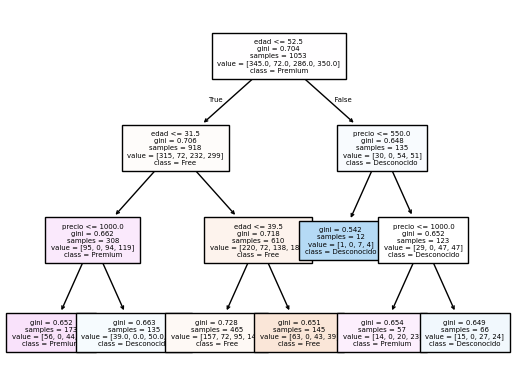

In [55]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.Figure(figsize=[50, 25], dpi=500)
plot_tree(
    decission_tree,
    filled = True,
    feature_names = ['edad', 'precio'],
    class_names = ['Free', 'Basic', 'Desconocido','Premium'],
    fontsize = 5
)

plt.show()

In [56]:
from sklearn.tree import export_text

tree_rules = export_text(decission_tree, feature_names=['edad', 'precio'])
print(tree_rules)

|--- edad <= 52.50
|   |--- edad <= 31.50
|   |   |--- precio <= 1000.00
|   |   |   |--- class: Premium
|   |   |--- precio >  1000.00
|   |   |   |--- class: Free
|   |--- edad >  31.50
|   |   |--- edad <= 39.50
|   |   |   |--- class: Basic
|   |   |--- edad >  39.50
|   |   |   |--- class: Basic
|--- edad >  52.50
|   |--- precio <= 550.00
|   |   |--- class: Free
|   |--- precio >  550.00
|   |   |--- precio <= 1000.00
|   |   |   |--- class: Premium
|   |   |--- precio >  1000.00
|   |   |   |--- class: Free



In [57]:
#Getting the inportance of each feature
print(decission_tree.feature_importances_)

[0.86824632 0.13175368]


### Hyperparameter Tuning

In [ ]:
depth_accuracy = []
depth_X_accuracy = []

for k in range(1, 16):
    acc_decission_tree = DecisionTreeClassifier( criterion = 'gini', max_depth = k, random_state = 42)
    acc_decission_tree.fit(X_train, y_train)

    y_pred_tree = acc_decission_tree.predict(X_test)
    t_acc = accuracy_score(y_pred = y_pred_tree, y_true = y_test)
    depth_accuracy.append(t_acc)

    y_train_test = acc_decission_tree.predict(X_train)
    t_acc = accuracy_score(y_pred = y_train_test, y_true = y_train)
    depth_X_accuracy.append(t_acc)

print(depth_accuracy)
print(depth_X_accuracy)



[0.29924242424242425, 0.3522727272727273, 0.3560606060606061, 0.3446969696969697, 0.3446969696969697, 0.3446969696969697, 0.3446969696969697, 0.3446969696969697, 0.3446969696969697, 0.3446969696969697, 0.3446969696969697, 0.3446969696969697, 0.3446969696969697, 0.3446969696969697, 0.3446969696969697]
[0.3504273504273504, 0.3732193732193732, 0.3798670465337132, 0.3912630579297246, 0.39411206077872746, 0.39411206077872746, 0.39411206077872746, 0.39411206077872746, 0.39411206077872746, 0.39411206077872746, 0.39411206077872746, 0.39411206077872746, 0.39411206077872746, 0.39411206077872746, 0.39411206077872746]


## How to Save a Trained Model for Predicting in the Future

*Joblib* is the standar library with the necesary tools for saving Scikit-Learn Models.

joblib.dumb(trained_model, 'file_name_string.pkl')

In [ ]:
#Import the joblib library
import joblib

In [ ]:
#Saving the model in a file
joblib.dump(decission_tree, 'pred_sub_ft_age_price.pkl')

['pred_sub_ft_age_price.pkl']

### How to Retrieve the Model

In [61]:
loaded_model = joblib.load('pred_sub_ft_age_price.pkl')

In [ ]:
loaded_pred = loaded_model.predict(pd.DataFrame([[28, 450]], columns = ['edad', 'precio']))
print(f"A person that is 28 years old and has spent 450€ is predicted to have the subscription: {loaded_pred[0]}")

A person that is 28 years old and has spent 450€ is predicted to have the subscription: Premium


In [67]:
# from sklearn.metrics import classification_report

print(classification_report(y_true = y_test, y_pred = y_pred_tree))

              precision    recall  f1-score   support

       Basic       0.36      0.67      0.47        87
 Desconocido       0.00      0.00      0.00        18
        Free       0.29      0.20      0.23        71
     Premium       0.41      0.25      0.31        88

    accuracy                           0.36       264
   macro avg       0.26      0.28      0.25       264
weighted avg       0.33      0.36      0.32       264



c:\Users\amgar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\amgar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\amgar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### Balance the Weight of Classes

In [68]:
decission_tree = DecisionTreeClassifier(criterion = 'gini', max_depth = 3, random_state = 42, class_weight = 'balanced')
decission_tree.fit(X_train, y_train)

y_pred = decission_tree.predict(X_test)
print(classification_report(y_true = y_test, y_pred = y_pred))

              precision    recall  f1-score   support

       Basic       0.41      0.17      0.24        87
 Desconocido       0.15      1.00      0.25        18
        Free       0.34      0.41      0.37        71
     Premium       0.50      0.10      0.17        88

    accuracy                           0.27       264
   macro avg       0.35      0.42      0.26       264
weighted avg       0.40      0.27      0.25       264



## Random Forest

In [69]:
#Import of the random forest classifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
#Initializing a random forest model
rdom_forest_model = RandomForestClassifier(
    random_state = 42, #Using always the same seed 
    n_estimators = 100, #Number of trees trained
    max_depth = 2, #Number of leaves depth
    criterion = 'gini' #Classification method
    # class_weight= 'balanced'
    )

#Fitting random forest model
rdom_forest_model.fit(X_train, y_train)

#Testing the model
y_pred = rdom_forest_model.predict(X_test)

#Printing the report
print(classification_report(y_true = y_test, y_pred = y_pred))

              precision    recall  f1-score   support

       Basic       0.37      0.63      0.47        87
 Desconocido       0.00      0.00      0.00        18
        Free       0.21      0.06      0.09        71
     Premium       0.43      0.48      0.45        88

    accuracy                           0.38       264
   macro avg       0.25      0.29      0.25       264
weighted avg       0.32      0.38      0.33       264



c:\Users\amgar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\amgar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\amgar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Through this notebook 'Desconocido' in 'suscripcion' variable has been seen as a valid class as the other three classes. However, the that class was built artificially (imputed) from the rows with NaN as value cells corresponding to that variable. Furthermore, classes with a significant lower number of instances creates a high difficultity for the algorithms to find and learn patterns.